<a href="https://colab.research.google.com/github/jeremiegiraud/3DMC_Workshop2/blob/main/Nullspace/nullspace_synthetic_example.ipynb#" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nullspace for potential field data: synthetic example. 

*Jeremie Giraud, Vitaliy Ogarko* <br>
Notebook adapted by *Jeremie Giraud* and *Guillaume Pirot*. 

This Notebook uses an extension of the algorithm proposed by: <br> 
Algorigthm adapted from Fichtner A, Zunino A. Hamiltonian Nullspace Shuttles. Geophys Res
Letters 2019 Jan 28;46(2):644-651. doi: 10.1029/2018GL080931, 2019.

This implementation is the builds up on:  <br> 
Giraud, J., Ford, M., Caumon, G., Ogarko, V., Grose, L., Martin, R., and Cupillard, P.: Geologically constrained geometry inversion and null-space navigation to explore alternative geological scenarios: a case study in the Western Pyrenees, Geophysical Journal International,
https://doi.org/10.1093/gji/ggae192, 2024.


## Licence

This work is licensed under a  
[Creative Commons Attribution-NonCommercial-NoDerivatives 4.0 International License](https://creativecommons.org/licenses/by-nc-nd/4.0/).

![CC BY-NC-ND 4.0](https://licensebuttons.net/l/by-nc-nd/4.0/88x31.png)

<div class="alert alert-block alert-warning">
This work has not yet been released to the public and contains unpublished research material. You cannot use it for commercial purposes or for publication until it has been released under another license.
</div>

In [ ]:

!git clone https://github.com/jeremiegiraud/workshop2_nullspace.git
%cd workshop2_nullspace
!rm -rf workshop2_nullspace
!pip install scikit-fmm
!pip install vtk


# Imports
import numpy as np
from pathlib import Path

# The package can be installed via "pip install ."
from tomofast_utils import load_sensit_from_tomofastx
import tomofast_reading_utils as tr
from input_params import read_input_parameters
import nullspace_utils as nu
import forward_calculation_utils as fcu
import nullspace_solver as ns
import nullspace_plot as npt
import time
# from IPython.display import display, Markdown


------------------------------------------------------------------------------------------------------------------
### Define the function managing the navigation. 
Using the inputs parameters from `par`, the `solve` function will: 
- define classes for grid, models, and plots
    - `gpars`, `mvars`, `ppars` 
- load the inputs models 
    - starting model;
    - perturbation;
    - mask if selected; 
    - gravity or magnetic data;
    - background data is necessary.
- call the nullspace solver and collect the results. 
    - function `nullspace_navigation`
- print some information for the user and save the ouputs. 
    - Models and data, for Paraview. 

<div class="alert alert-block alert-info">
<b>What to do:</b> Nothing to do here, it is just for your information or to have a look. <br> 
Execute and go to the next cell.
</div>

In [4]:
def solve(par):
    """
    This function is called to run null space navigation using parameters contained in the class par.
    :param par: a class containing file paths to input data and parameters for the solver.
    """

    # Unpacking parameter class 'par'.

    sensit_path = par.sensit_path
    tomofast_sensit_nbproc = par.tomofast_sensit_nbproc
    use_rotation_matrix = par.use_rotation_matrix
    unit_conv = par.unit_conv
    use_mask_domain = par.use_mask_domain
    weight_prior_model = par.weight_prior_model
    weight_pos_const = par.weight_pos_const
    sensit_type = par.sensit_type
    rotation_mat_filename = par.rotation_mat_filename
    geol_model_path = par.geol_model_path
    data_vals_filename = par.data_vals_filename
    data_background_filename = par.data_background_filename
    perturbation_filename = par.perturbation_filename
    save_intermediate_plots = par.save_intermediate_plots
    interval_intermediate_plots = par.interval_intermediate_plots

    # Sanity check on some input parameters. 
    if unit_conv==True and sensit_type=="magn": 
        print("\n**Incompatible input argument. Currently, unit conversion is supported only for gravity data.**")
        unit_conv==False
        print("\033[91m unit_conv will be set to False. \033[0m \n")

    if sensit_type=="grav" and weight_pos_const > 0:
        print("\n**Incompatible input argument. The positivity constraint should be applied only to mag data.**")
        print("\033[91m weight_pos_const will be set to 0. \033[0m \n")
        weight_pos_const = 0.        

    # Initialize model parameters class.
    gpars = ns.GridParameters()

    # Initialise model variables class.
    mvars = ns.ModelsVariables()

    # Set the dimensions of the model (nz, nx, ny).
    gpars.dim = (par.nz, par.nx, par.ny)

    # Init plotting parameters class.
    ppars = npt.PlotParameters(plot_thresh=0.66*par.max_change, colm=par.max_change, slice_x=round(par.nx/2), slice_z=9, 
                               save_intermediate_plots=save_intermediate_plots, 
                               interval_intermediate_plots=interval_intermediate_plots)  # slice_z=12 also interesting.

    # ----------------------------------------------------------------------------------
    # Read the model and model grid.
    model_filename = par.model_filename
    # mvars.m_beg: starting point for the nullspace navigation (unperturbed model).
    mvars.m_beg, gpars = tr.read_tomofast_model(model_filename, gpars)

    # Geological model for plots and comparison (not used in computation: only for plots).
    mvars.m_geol_orig, _ = tr.read_tomofast_model(geol_model_path, gpars)

    # ----------------------------------------------------------------------------------
    # Setup for saving plots.
    save_plots = par.save_plots

    # Create output folder for plots.
    if save_plots:
        folder_path = Path(par.path_output)
        folder_path.mkdir(parents=True, exist_ok=True)
        temporary_path = Path('./temporary_plots/')  # This value is used in nullspace_navigation.
        temporary_path.mkdir(parents=True, exist_ok=True)

    # ----------------------------------------------------------------------------------
    # Pre-processing parameters: definition of mask.
    # Index of rock unit for perturbation and null space analysis (rocks indexed by increasing density).
    ind_unit_mask = par.ind_unit_mask  # Index used for the calculation of the mask. In Pyrenees paper: 9 = Mantle.
    # Distance max in number of cells away from the outline of rock unit with index 'ind_unit_mask'.
    distance_max = par.distance_max  # In Pyrenees paper: 8 in tests shown.
    # ----------------------------------------------------------------------------------
    # Calculate the domain mask: cells where the solver is allowed to change the model values.
    # The domain mask is used to reduce the part of the model that can be affected by null space navigation.
    # We define the compute domain with masks on distance to the outline of selected unit (if applicable).
    mvars.domain_mask = nu.get_masked_domain(use_mask_domain, distance_max, ind_unit_mask, mvars.m_beg)

    # ----------------------------------------------------------------------------------
    # Reading the geophy data.

    # Initialise geophy data class.
    geophy_data = nu.GeophyData()

    tr.read_tomofast_data(geophy_data, data_vals_filename, data_type='field')
    tr.read_tomofast_data(geophy_data, data_vals_filename, data_type='calc')
    tr.read_tomofast_data(geophy_data, data_background_filename, data_type='background')

    # ----------------------------------------------------------------------------------
    # Load sensitivity kernel from Tomofast-x.
    if par.sensit is None:
        par.sensit = load_sensit_from_tomofastx(sensit_path, nbproc=tomofast_sensit_nbproc, type=sensit_type, verbose=False)
    print('\n')
    # ----------------------------------------------------------------------------------

    # Initialise solver parameters parameters.
    shpars = ns.SolverParameters(eps=par.eps,
                                 max_change=par.max_change,
                                 num_epochs=par.num_epochs,
                                 time_step=par.time_step,
                                 weight_prior=weight_prior_model,
                                 weight_pos_const=weight_pos_const)  
    
    # Load model perturbation: the model change we want to impose (the final model should have this change).
    mvars.delta_m_orig, _ = tr.read_tomofast_model(perturbation_filename, gpars)

    # ----------------------------------------------------------------------------------
    # Initialization of nullspace navigation.
    # ----------------------------------------------------------------------------------
    # Null space shuttle: perturbation to apply during null space exploration.
    mvars.delta_m = mvars.delta_m_orig

    # Initialising a class setting up the nullspace shuttle using Fichtner and Zunino (2019).
    nsvars = ns.NullSpaceNavigationVars(mvars.delta_m, shpars.eps)

    # Initialise models for nullspace navigation.
    mvars.m_nullspace_orig = mvars.m_beg.flatten().copy()
    mvars.m_nullspace_subs = mvars.m_nullspace_orig

    mvars.m_beg = mvars.m_nullspace_subs.copy()  # Starting point for nullspace navigation.
    mvars.m_curr = mvars.m_nullspace_orig.copy()  # Current model.

    # ----------------------------------------------------------------------------------

    # %% ----------------------------------------------------------------------------------
    # Do the nullspace navigation. Stops when the perturbation reaches par.max_change or after par.num_epochs.
    # Calculate response of perturbation mvars.delta_m_orig and its RMS.
    geophy_data_deltam = fcu.calc_fwd(par.sensit, mvars.delta_m.flatten(), unit_conv, use_csr_matrix=True)

    fcu.calc_geophy_data(geophy_data, par.sensit, mvars.m_curr, bouguer_anomaly=True, use_csr_matrix=True, unit_conv=unit_conv,base_model=None)
    
    rms_pert = fcu.calc_data_rms(geophy_data_deltam)
    rms_data_misfit = fcu.calc_data_rms(geophy_data)
    print(str("RMS of perturbation for nullspace navigation:"), format(rms_pert, ".5f"), str(' SI'))
    print(str("RMS of data misfit *before* nullspace navigation:"), format(rms_data_misfit, ".4f"), str(' SI'))

    geophy_data, misfit_data, kinetic_energy, model_misfit, positivity_misfit, mvars = ns.nullspace_navigation(shpars, mvars, nsvars,
                                                                                          par.sensit, geophy_data, unit_conv, gpars, ppars)

    # TODO: add the unit in the geophy_data dataclass, in order to remove the input argument unit_conv? 

    # Print final data RMS error.
    print(str("Data misfit after null space navigation:"), format(misfit_data[misfit_data>0][-1] , ".3f"), str(' SI'))

    # Calculate response of the difference between the original (starting) and final model and its RMS.
    m_diff = nu.calc_model_diff(mvars.m_curr, mvars.m_nullspace_orig)
    geophy_data_mdiff = fcu.calc_fwd(par.sensit, m_diff, unit_conv, use_csr_matrix=True)

    # Print some info about the models. 
    print('\nMaximum value of the difference between reference and final model: ', np.max(m_diff))
    print('Maximum value of the referencen model: ', np.max(mvars.m_nullspace_orig))
    print('Maximum value of the perturbation model: ', np.max(mvars.delta_m_orig))
    
    rms_mdiff = fcu.calc_data_rms(geophy_data_mdiff)
    print(str("\nRMS data of diff between orig - final model:"), format(rms_mdiff, ".2f"), str(' mGal'))

    rms_data_misfit = fcu.calc_data_rms(geophy_data)
    print(str("RMS of data misfit *after* nullspace navigation:"), format(rms_data_misfit, ".2f"), str(' SI'))

    # %% ===============================================================================================
    # Setting up plots and visual analysis.
    # Models to plot - 2x2 subplots.
    # ===============================================================================================
    # Set plot properties.
    npt.set_plotprops()

    # Calculate Hamiltonian and its different terms for analysis.
    hamiltonian_quantities = ns.HamiltonQuantities(kinetic_energy, misfit_data, model_misfit, positivity_misfit, unit_conv,
                                                   weight_prior_model, weight_pos_const)

    # Define plot parameters.
    ppars = npt.prepare_plots(gpars.dim, mvars, m_diff, ppars, 
                              xlims=[np.min(gpars.x.min()), np.min(gpars.x.max())], 
                              ylims=[np.min(gpars.y.min()), np.min(gpars.y.max())])

    # Find where differences above a certain threshold are located -- used for the scatter plot.
    ind_bigdiff_all, ind_bigdiff_slice = npt.get_large_diff(gpars, ppars, mvars.m_curr, mvars.m_nullspace_orig)

    # Get rotation matrix used to define the mesh for inversion: needed to relocate data in their geographical location.
    rotation_matrix = nu.get_rotation_matrix(use_rotation_matrix, rotation_mat_filename)

    # %% ===============================================================================================
    # Save the data and models for future visualization. 
    # ===============================================================================================

    # Save models for viz with VTK.
    npt.save_model_to_vtk(mvars.m_curr, gpars, filename=par.path_output + '/voxet_m_curr_final', save=save_plots)
    npt.save_model_to_vtk(mvars.m_nullspace_orig, gpars, filename=par.path_output + '/m_nullspace_orig', save=save_plots)
    npt.save_model_to_vtk(mvars.delta_m_orig, gpars, filename=par.path_output + '/delta_m_orig', save=save_plots)
    npt.save_model_to_vtk(m_diff, gpars, filename=par.path_output + '/model_diffs', save=save_plots)

    # Save data for viz with VTK.
    npt.save_data_to_vtk(geophy_data, datatype_to_save='data_field', filename=par.path_output + '/data_field', save=save_plots)
    npt.save_data_to_vtk(geophy_data, datatype_to_save='data_calc', filename=par.path_output + '/data_calc', save=save_plots)
    npt.save_data_to_vtk(geophy_data, datatype_to_save='difference', filename=par.path_output + '/data_diff', save=save_plots)

    # Save metrics for monitoring of the evolution of model perturbation. 
    npt.save_metrics_csv(misfit_data, hamiltonian_quantities, filename='metrics_file', save=True)
    print('\n')

    # %% ===============================================================================================
    # Do the plotting.
    # ===============================================================================================

    # Plot a depth slice with before/after/differences.
    '''
    fig_depthslice = npt.plot_navigation_depthslice(gpars, ppars, rotation_matrix, ind_bigdiff_all)
    # Plot a vertical cross section with before/after/differences
    '''
    fig_xsection = npt.plot_navigation_xsection(gpars, ppars, ind_bigdiff_slice)

    # Plot modelling metrics.
    fig_metrics = npt.plot_metrics_perturbation(misfit_data, hamiltonian_quantities)
    # Plot the data. 
    # fig_data = npt.plot_data(geophy_data, geophy_data_deltam, rotation_matrix)

    # Save the plots.
    # npt.save_plot(fig=fig_depthslice, filename=par.path_output + '/Differences_DepthSlice', ext='.png', save=save_plots)
    # npt.save_plot(fig=fig_xsection, filename=par.path_output + '/Differences_VertSlice', ext='.png', save=save_plots)
    npt.save_plot(fig=fig_metrics, filename=par.path_output + '/Metrics', ext='.png', dpi=300, save=save_plots)
    # npt.save_plot(fig=fig_data, filename=par.path_output + '/Geophy_data', ext='.png', dpi=300, save=save_plots)

    return par


Example of a large perturbation for **magnetic data**:

<!-- ![Image](images_notebooks/starting_model_perturbation_mag.png) -->
<img src="images_notebooks/starting_model_perturbation_mag.png" alt="Description" width="600"/>

Example of a large perturbation for **gravity data** (unit: kg/m3):

<img src="images_notebooks/starting_model_perturbation_grav.png" alt="Description" width="600"/>

------------------------------------------------------------------------------------------------------------------
#### Iterations during the navigation
<br>
<img src="images_notebooks/equation_leapfrog.png" alt="Description" width="600"/>

while $\psi^d \leq \epsilon$

### Tuning the parameters

`par.time_step` = $\Delta t$ <br>
`par.num_epochs` = number of perturbations <br>
`par.eps` = $\epsilon$ <br>
$\gamma = f(\epsilon)$

- larger `par.time_step` $\Rightarrow$ larger updates. 
- larger `par.eps` $\Rightarrow$ more freedome to increase the data misfit. 
- larger `par.num_epochs` $\Rightarrow$ larger number of iterations. 

### Additional parameter <br>
`par.max_change` = stop the process when somewhere in the model |m_start - m_current| $\geq$ `par.max_change`


Below are the parameters that can be changed to adjust the nullspace navigation. 
For a given parameter, the first line is a value proposed for gravity data. The second line corresponds for the same parameter, but for the magnetic case. 

The next cell reads the default parameters from a parameter file that can be adjusted by the user. 
After execution of the cell, the contents of the file are printed. 

<div class="alert alert-block alert-warning">
<b>What to do:</b> One thing to do - provide the path to the parfile. <br> Then execute and go to the next cell.
</div>

In [5]:
# Relative path to the notebook.
# parfile_path  ="parfiles/Parfile_example_grav.txt"  # Grav. 
parfile_path  ="parfiles/Parfile_example_magn.txt"  # Magn.

# Read default input parameters.
par = read_input_parameters(parfile_path, print_values=True)

Provided Parfile path: parfiles/Parfile_example_magn.txt
----------------- READING THE PARFILE ----------------- 


 ------ FilePaths ------
model_filename = data/models/model_grid_example_magsusc.txt
perturbation_filename = data/models/delta_m_orig_example_magsusc.txt
data_vals_filename = data/magnetic_data/data_vals_example_magsusc_noisy.txt
data_background_filename = data/magnetic_data/data_background_example_magsusc.txt
path_output = output_example
sensit_path = data/SENSIT_example_magn_compression/
geol_model_path = data/models/delta_m_orig_example.txt
data_outline_filename = data/gravity_data/data_outline_example.txt

 ------ SolverParameters ------
sensit_type = magn
tomofast_sensit_nbproc = 5
use_rotation_matrix = False
unit_conv = False
use_mask_domain = False
eps = 1.e-2
max_change = 0.2
num_epochs = 100
time_step = 5.e-3
weight_prior_model = 0.
weight_pos_const = 100.

 ------ GridParameters ------
nx = 22
ny = 147
nz = 39

 ------ PreProcessingParameters ------
ind_unit_mas


<div class="alert alert-block alert-warning">
<b>What to do:</b> This is your turn. <br>
Start by executing with the proposed values, then look at the results and change the parameters at will...
</div>

> <br>
> Write your comments here if you like.<br>
> e.g., interest parameters or questions.
> <br>
> <br>



--------- Started nullspace navigation ---------

Sensitivity matrix from Tomofastx: loaded.


RMS of perturbation for nullspace navigation: 41.09866  SI
RMS of data misfit *before* nullspace navigation: 0.9594  SI
 |██████████████████████████████████████████████████| 100.0%  sum(ReLU(-m[m<0])**2).=0.0018 misfit=0.89 SI
Data misfit after null space navigation: 0.892  SI

Maximum value of the difference between reference and final model:  0.012094830670262024
Maximum value of the referencen model:  0.05
Maximum value of the perturbation model:  0.02

RMS data of diff between orig - final model: 1.10  mGal
RMS of data misfit *after* nullspace navigation: 0.89  SI

Plot parameters are hardcoded in function prepare_plots in file nullspace_plot.py
VTK data file saved as: output_example/data_field.vtp
VTK data file saved as: output_example/data_calc.vtp
VTK data file saved as: output_example/data_diff.vtp
Data misfit evolution and Hamiltonian metrics saved in: metrics_file.csv




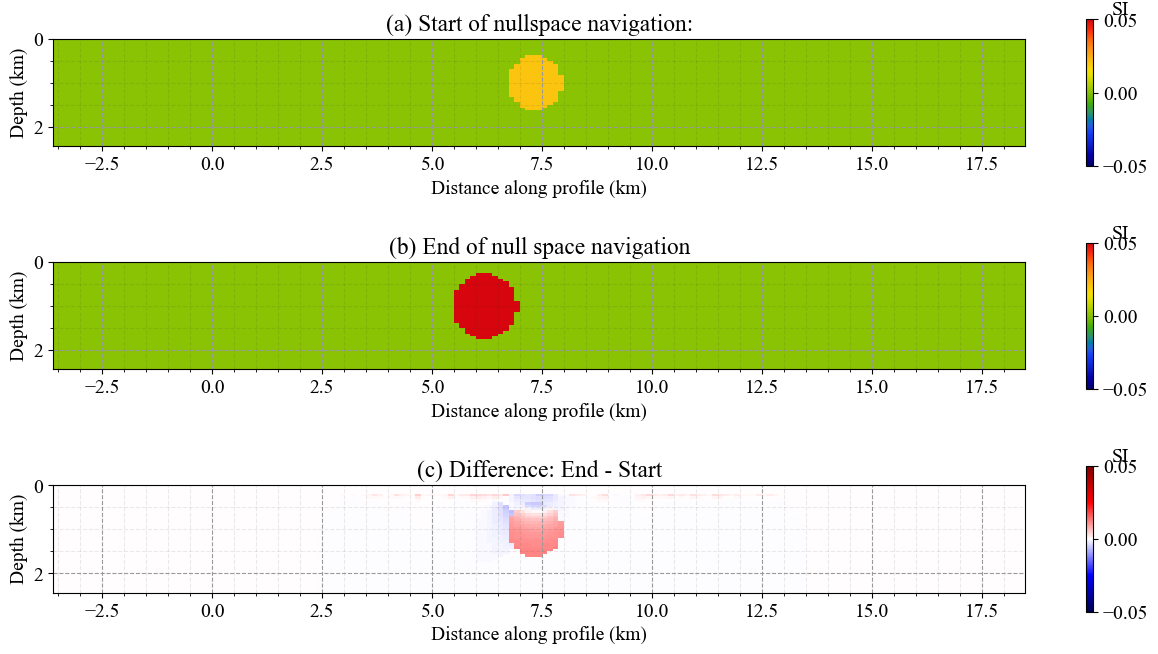

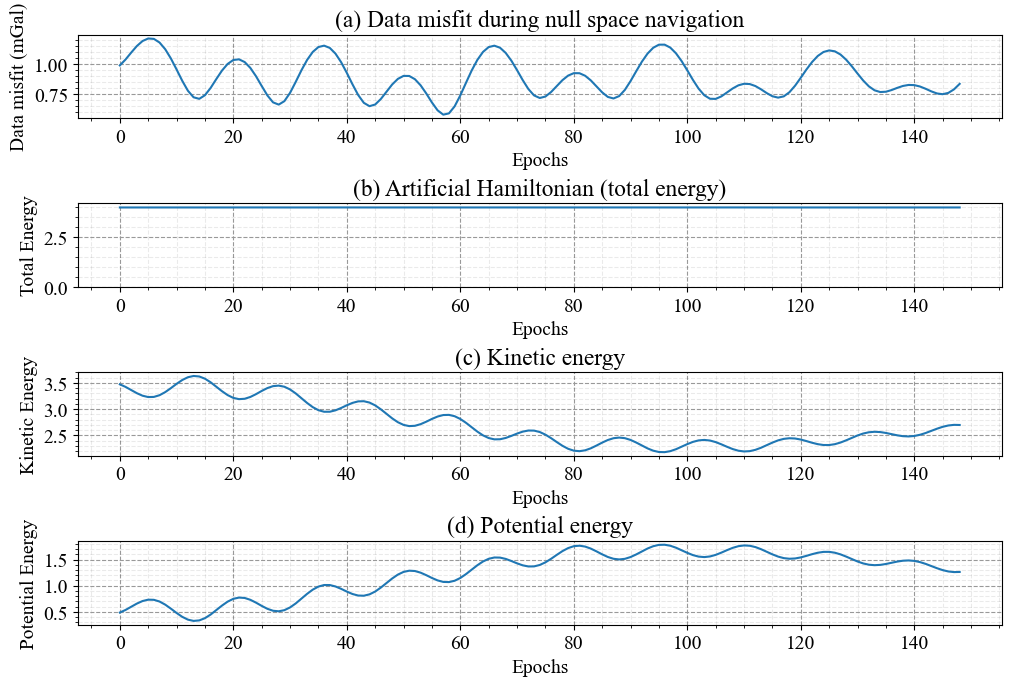

RUN TIME:  15.393552303314209 sec


In [6]:
# ------------[    SOLVER PARAMETERS    ]------------ #  
# Tolerance on misfit variations.
# par.eps = 3.e-4  # Grav. 
par.eps = 3.5  # Magn.

# Stops iterations if different with starting model is higher that this value (in kg/m^3 for grav, in SI for magn).
# par.max_change = 200  # Grav. 
par.max_change = 0.2  # Magn.

# Maximum number of time steps (= iterations).
# par.num_epochs = 1000  # Grav. 
par.num_epochs = 150  # Magn.

# Length of a time step (scales the perturbation at each iteration: small time_step => small perturbation).
# par.time_step = 1000.  # Grav. 
par.time_step = 1.e-3  # Magn.

# BETA. Weight of prior model term in cost function. (Negative: larger departures from the original model, Positive: smaller variations. Depth weight can be used here.)
# par.weight_prior_model = +1.e-11  # 1.e-11 for grav. 

# BETA. Strenght of positivity constraints. Recommended for magn. only.
# par.weight_pos_const = 0.  # Not for grav!
par.weight_pos_const = 1000  # Magn only!

# ------------[    SAVING OUTPUTS    ]------------ #
# Flag controlling whether plots will be saved. 
par.save_plots = True

# Flag controlling whether intermediate results will be saved.
par.save_intermediate_plots = True

# Interval at which intermediate results will be saved.
par.interval_intermediate_plots = np.inf  # e.g. 20 save 1 model every 20 models. 

# ----------- [ Now running the Nullspace navigation. ] ----------- #
print('\n--------- Started nullspace navigation ---------\n')

# Record the start time
start_time = time.time()

# Run the solver.
solve(par)

# Print the elapsed time
print('RUN TIME: ', time.time() - start_time, 'sec') 